# Kaggle-Style Weighting & Backtesting
**Strategy:** Linear Time Weighting (0.1 to 1.0) with Multi-Fold Backtesting.
**Goal:** Validate if favoring recent data improves MAE for the 548-day horizon.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import xgboost as xgb
from sklearn.metrics import mean_absolute_error
import sys
import os

sys.path.append(os.path.abspath('..'))
from src.config import Config

pd.set_option('display.max_columns', None)
Config.initialize_dirs()

## 1 — Data & Features

In [2]:
sales = pd.read_parquet(Config.PROCESSED_DATA_DIR / "sales.parquet")
sales['Date'] = pd.to_datetime(sales['Date'])

def extract_features(df_input, start_ref):
    df = df_input.copy()
    df['days_from_start'] = (df['Date'] - start_ref).dt.days
    df['trend_dampened'] = np.log1p(df['days_from_start'])
    df['year'] = df['Date'].dt.year
    df['month'] = df['Date'].dt.month
    df['day_of_week'] = df['Date'].dt.dayofweek
    df['day_of_year'] = df['Date'].dt.dayofyear
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    return df

full_df = extract_features(sales, sales['Date'].min())
features = ['trend_dampened', 'year', 'month', 'day_of_week', 'day_of_year', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']
targets = ['Revenue', 'COGS']

## 2 — Linear Weighting Logic
Generating weights from 0.1 (start) to 1.0 (end of training).

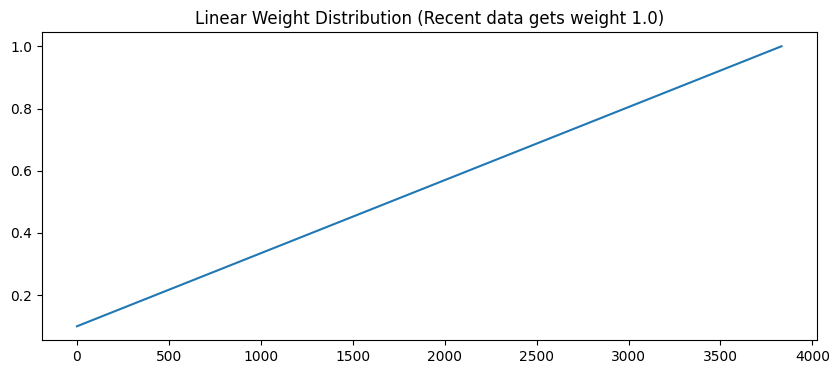

In [3]:
def get_linear_weights(df_train):
    n = len(df_train)
    return np.linspace(0.1, 1.0, n)

plt.figure(figsize=(10, 4))
plt.plot(get_linear_weights(full_df))
plt.title("Linear Weight Distribution (Recent data gets weight 1.0)")
plt.show()

## 3 — 2-Fold Backtesting
- **Fold 1:** Train 2012-2020, Valid 2021
- **Fold 2:** Train 2012-2021, Valid 2022

In [4]:
folds = [
    (2021, "Fold 1 (Predicting 2021)"), 
    (2022, "Fold 2 (Predicting 2022)")
]

results = []

for valid_year, label in folds:
    print(f"\n>>> {label}")
    df_train = full_df[full_df['Date'].dt.year < valid_year]
    df_val = full_df[full_df['Date'].dt.year == valid_year]
    
    sw = get_linear_weights(df_train)
    total_mae = 0
    
    for target in targets:
        # LGBM with weights
        lgbm = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.03, objective='regression_l1', random_state=42, verbose=-1)
        lgbm.fit(df_train[features], df_train[target], sample_weight=sw)
        
        # XGB with weights
        xgbr = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.03, objective='reg:absoluteerror', random_state=42)
        xgbr.fit(df_train[features], df_train[target], sample_weight=sw)
        
        preds = (lgbm.predict(df_val[features]) + xgbr.predict(df_val[features])) / 2
        mae = mean_absolute_error(df_val[target], preds)
        print(f"  {target} MAE: {mae:,.0f}")
        total_mae += mae
        
    print(f"  Total Fold MAE: {total_mae:,.0f}")
    results.append(total_mae)

print(f"\nAverage Backtest MAE: {np.mean(results):,.0f}")


>>> Fold 1 (Predicting 2021)
  Revenue MAE: 612,592
  COGS MAE: 537,429
  Total Fold MAE: 1,150,021

>>> Fold 2 (Predicting 2022)
  Revenue MAE: 736,869
  COGS MAE: 616,831
  Total Fold MAE: 1,353,700

Average Backtest MAE: 1,251,860
